In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

from sklearn.metrics import roc_auc_score, accuracy_score,classification_report


import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

from imblearn.over_sampling import SMOTE

In [2]:
df=pd.read_csv(r'F:\processing_projects\machine_learnning\churn\churn_prediction.csv')
df.head()

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,days_since_last_transaction,...,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn
0,1,3135,66,Male,0.0,self_employed,187.0,2,755,224.0,...,1458.71,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0
1,2,310,35,Male,0.0,self_employed,NaN,2,3214,60.0,...,8704.66,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0
2,4,2356,31,Male,0.0,salaried,146.0,2,41,NaN,...,5815.29,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0
3,5,478,90,NaN,NaN,self_employed,1020.0,2,582,147.0,...,2291.91,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1
4,6,2531,42,Male,2.0,self_employed,1494.0,3,388,58.0,...,1401.72,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1


In [3]:
df.shape

(28382, 21)

In [4]:
df.describe()

,customer_id,vintage,age,dependents,city,customer_nw_category,branch_code,days_since_last_transaction,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn
count,28382.000000,28382.000000,28382.000000,25919.000000,27579.000000,28382.000000,28382.000000,25159.000000,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,28382.000000
mean,15143.508667,2364.336446,48.208336,0.347236,796.109576,2.225530,925.975019,69.997814,7.380552e+03,7.495771e+03,7.496780e+03,7.124209e+03,3.433252e+03,3.261694e+03,3.658745e+03,3.339761e+03,7.451133e+03,7.495177e+03,0.185329
std,8746.454456,1610.124506,17.807163,0.997661,432.872102,0.660443,937.799129,86.341098,4.259871e+04,4.252935e+04,4.172622e+04,4.457581e+04,7.707145e+04,2.968889e+04,5.198542e+04,2.430111e+04,4.203394e+04,4.243198e+04,0.388571
min,1.000000,180.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,-5.503960e+03,-3.149570e+03,1.428690e+03,-1.650610e+04,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,-3.374180e+03,-5.171920e+03,0.000000
25%,7557.250000,1121.000000,36.000000,0.000000,409.000000,2.000000,176.000000,11.000000,1.784470e+03,1.906000e+03,2.180945e+03,1.832507e+03,3.100000e-01,3.300000e-01,4.100000e-01,4.100000e-01,1.996765e+03,2.074407e+03,0.000000
50%,15150.500000,2018.000000,46.000000,0.000000,834.000000,2.000000,572.000000,30.000000,3.281255e+03,3.379915e+03,3.542865e+03,3.359600e+03,6.100000e-01,6.300000e-01,9.193000e+01,1.099600e+02,3.447995e+03,3.465235e+03,0.000000
75%,22706.750000,3176.000000,60.000000,0.000000,1096.000000,3.000000,1440.000000,95.000000,6.635820e+03,6.656535e+03,6.666887e+03,6.517960e+03,7.072725e+02,7.492350e+02,1.360435e+03,1.357553e+03,6.667958e+03,6.654693e+03,0.000000
max,30301.000000,12899.000000,90.000000,52.000000,1649.000000,3.000000,4782.000000,365.000000,5.905904e+06,5.740439e+06,5.700290e+06,5.010170e+06,1.226985e+07,2.361808e+06,7.637857e+06,1.414168e+06,5.778185e+06,5.720144e+06,1.000000


In [5]:
df.drop(["customer_id",'branch_code','city'], inplace=True, axis=1)

In [6]:
def data_info(data):
    cols=[]
    unique_val=[]
    n_uniques=[]
    dtypes=[]
    nulls=[]
    for col in data.columns:
        cols.append(col)
        dtypes.append(data[col].dtype)
        n_uniques.append(data[col].nunique())
        unique_val.append(data[col].unique())
        nulls.append(data[col].isna().sum())
        
    return pd.DataFrame({"Col":cols,"dtype":dtypes,"n_uniques":n_uniques,"Unique Values":unique_val,"Nulls":nulls})
        

In [7]:
data_info(df)

,Col,dtype,n_uniques,Unique Values,Nulls
0,vintage,int64,5473,"[3135, 310, 2356, 478, 2531, 263, 5922, 1145, ...",0
1,age,int64,90,"[66, 35, 31, 90, 42, 72, 46, 40, 68, 32, 73, 5...",0
2,gender,object,2,"[Male, nan, Female]",525
3,dependents,float64,15,"[0.0, nan, 2.0, 3.0, 1.0, 7.0, 4.0, 6.0, 5.0, ...",2463
4,occupation,object,5,"[self_employed, salaried, retired, student, na...",80
5,customer_nw_category,int64,3,"[2, 3, 1]",0
6,days_since_last_transaction,float64,360,"[224.0, 60.0, nan, 147.0, 58.0, 98.0, 172.0, 1...",3223
7,current_balance,float64,27903,"[1458.71, 5390.37, 3913.16, 2291.91, 927.72, 1...",0
8,previous_month_end_balance,float64,27922,"[1458.71, 8704.66, 5815.29, 2291.91, 1401.72, ...",0
9,average_monthly_balance_prevQ,float64,27801,"[1458.71, 7799.26, 4910.17, 2084.54, 1643.31, ...",0


In [8]:
df.fillna(df.mean(numeric_only=True),inplace=True)

In [9]:
df.isna().sum()

vintage                             0
age                                 0
gender                            525
dependents                          0
occupation                         80
customer_nw_category                0
days_since_last_transaction         0
current_balance                     0
previous_month_end_balance          0
average_monthly_balance_prevQ       0
average_monthly_balance_prevQ2      0
current_month_credit                0
previous_month_credit               0
current_month_debit                 0
previous_month_debit                0
current_month_balance               0
previous_month_balance              0
churn                               0
dtype: int64

In [10]:
object_columns=df.select_dtypes(include=['object']).columns
for i in object_columns:
    if df[i].isnull().sum()>0:
        df[i]=df[i].fillna(df[i].mode()[0])

In [11]:
df.isnull().sum()

vintage                           0
age                               0
gender                            0
dependents                        0
occupation                        0
customer_nw_category              0
days_since_last_transaction       0
current_balance                   0
previous_month_end_balance        0
average_monthly_balance_prevQ     0
average_monthly_balance_prevQ2    0
current_month_credit              0
previous_month_credit             0
current_month_debit               0
previous_month_debit              0
current_month_balance             0
previous_month_balance            0
churn                             0
dtype: int64

In [12]:
df.duplicated().sum()

0

In [13]:
occ=df['occupation'].value_counts()
occ

occupation
self_employed    17556
salaried          6704
student           2058
retired           2024
company             40
Name: count, dtype: int64

In [14]:
gender=df['gender'].value_counts()
gender

gender
Male      17073
Female    11309
Name: count, dtype: int64

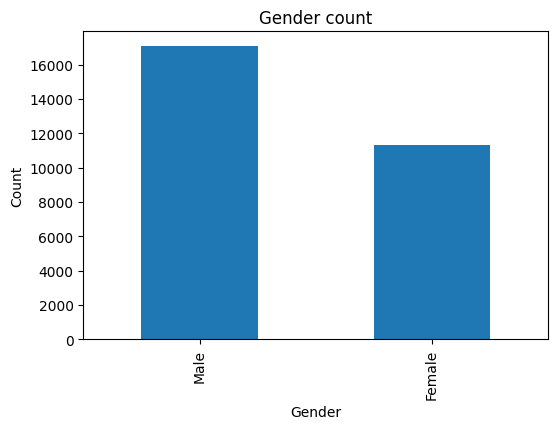

In [15]:
plt.figure(figsize=(6,4))
plt.title('Gender count')
gender.plot(kind='bar')
plt.xlabel('Gender')
plt.ylabel('Count') 
plt.show()

In [16]:
churn=df['churn'].value_counts()
churn

churn
0    23122
1     5260
Name: count, dtype: int64

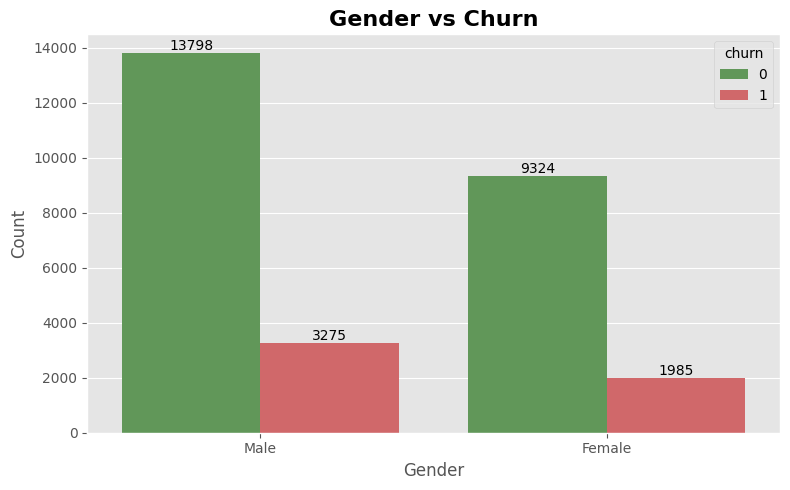

In [17]:
plt.style.use('ggplot')

plt.figure(figsize=(8,5))

palette = ['#59A14F', '#E15759']  # green = no churn, red = churn

ax = sns.countplot(data=df, x='gender', hue='churn', palette=palette)

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=10)

plt.title("Gender vs Churn", fontsize=16, fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


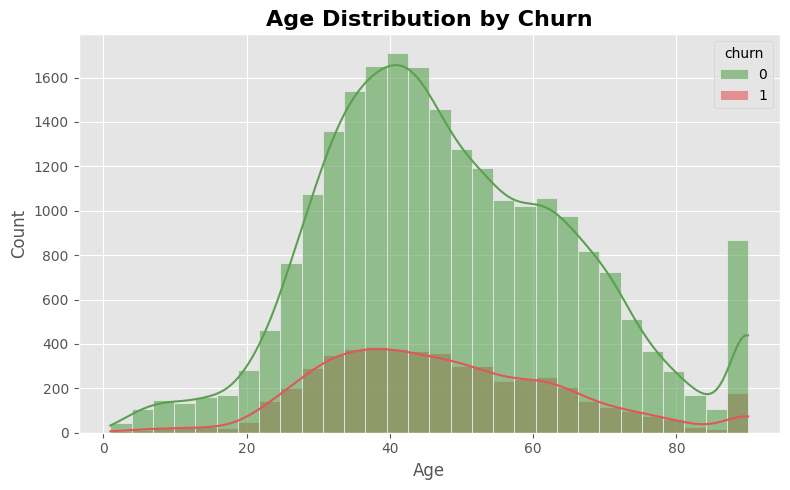

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='age',
    hue='churn',
    bins=30,
    kde=True,
    palette=['#59A14F', '#E15759'],
    alpha=0.6
)

plt.title("Age Distribution by Churn", fontsize=16, fontweight='bold')
plt.xlabel("Age")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


In [19]:
df["gender"] = df["gender"].replace({"Female": 0, "Male": 1}).astype('int64')

In [20]:
le = LabelEncoder()
df['occupation'] = le.fit_transform(df['occupation'])

In [21]:
data_info(df)


,Col,dtype,n_uniques,Unique Values,Nulls
0,vintage,int64,5473,"[3135, 310, 2356, 478, 2531, 263, 5922, 1145, ...",0
1,age,int64,90,"[66, 35, 31, 90, 42, 72, 46, 40, 68, 32, 73, 5...",0
2,gender,int64,2,"[1, 0]",0
3,dependents,float64,16,"[0.0, 0.34723561865812724, 2.0, 3.0, 1.0, 7.0,...",0
4,occupation,int32,5,"[3, 2, 1, 4, 0]",0
5,customer_nw_category,int64,3,"[2, 3, 1]",0
6,days_since_last_transaction,float64,361,"[224.0, 60.0, 69.99781390357327, 147.0, 58.0, ...",0
7,current_balance,float64,27903,"[1458.71, 5390.37, 3913.16, 2291.91, 927.72, 1...",0
8,previous_month_end_balance,float64,27922,"[1458.71, 8704.66, 5815.29, 2291.91, 1401.72, ...",0
9,average_monthly_balance_prevQ,float64,27801,"[1458.71, 7799.26, 4910.17, 2084.54, 1643.31, ...",0


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   vintage                         28382 non-null  int64  
 1   age                             28382 non-null  int64  
 2   gender                          28382 non-null  int64  
 3   dependents                      28382 non-null  float64
 4   occupation                      28382 non-null  int32  
 5   customer_nw_category            28382 non-null  int64  
 6   days_since_last_transaction     28382 non-null  float64
 7   current_balance                 28382 non-null  float64
 8   previous_month_end_balance      28382 non-null  float64
 9   average_monthly_balance_prevQ   28382 non-null  float64
 10  average_monthly_balance_prevQ2  28382 non-null  float64
 11  current_month_credit            28382 non-null  float64
 12  previous_month_credit           

<Axes: >

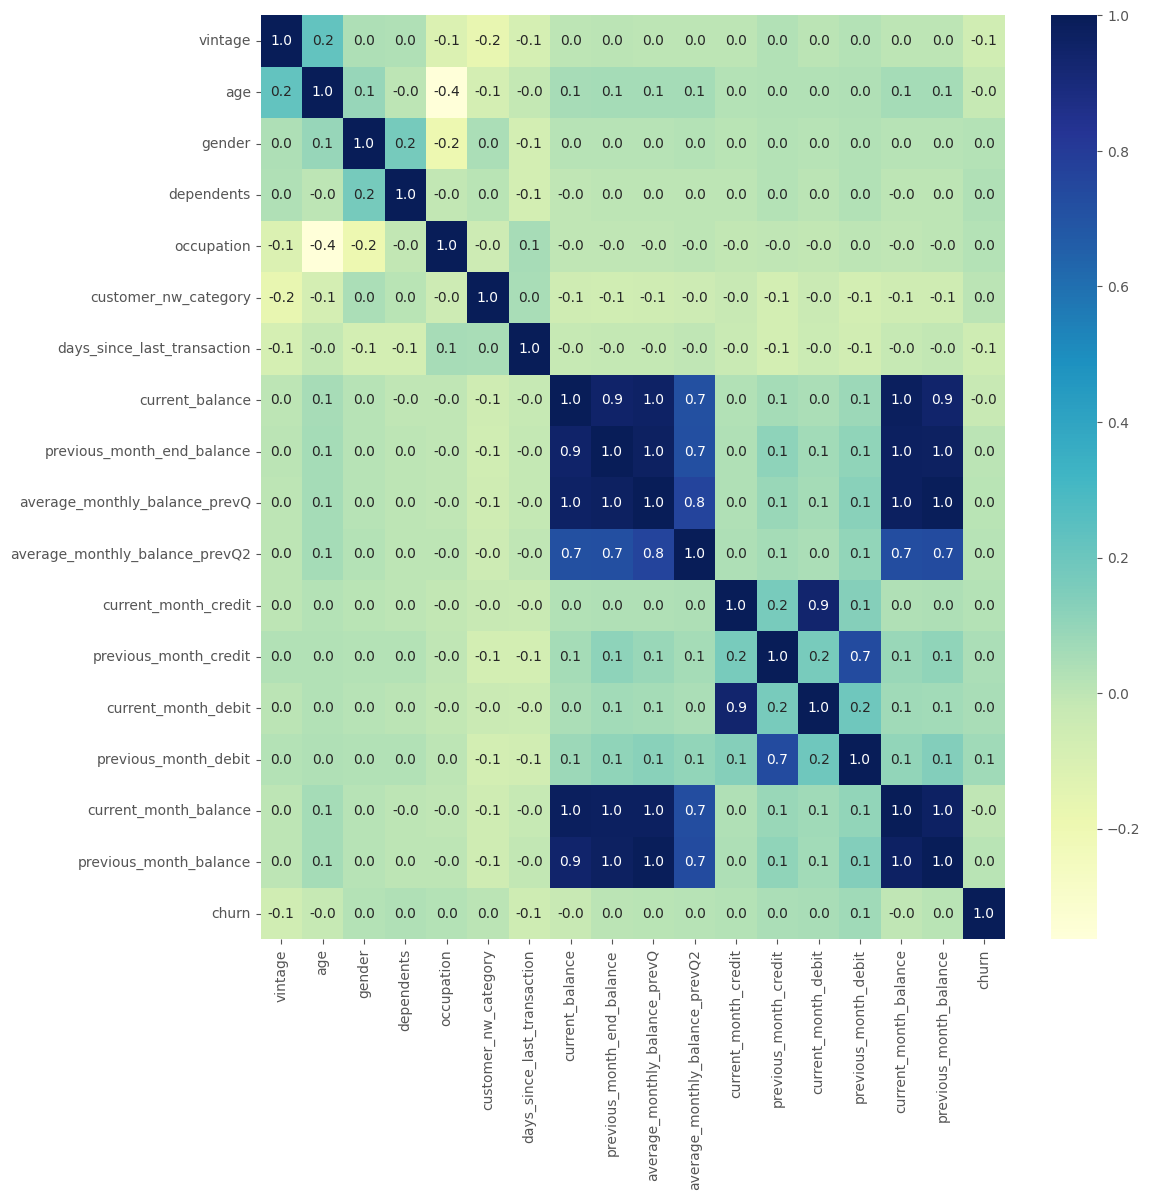

In [23]:

plt.figure(figsize=(12,12))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap = "YlGnBu",fmt = ".1f",cbar = True)

In [24]:
X = df.drop('churn', axis=1)
y = df['churn']


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [26]:
fs_model = RandomForestClassifier(n_estimators=300, random_state=42)
fs_model.fit(X_train, y_train)

importance = pd.Series(
    fs_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

TOP_K = 11
top_features = importance.head(TOP_K).index

print("Top Features:")
print(top_features)


Top Features:
Index(['current_balance', 'current_month_balance', 'current_month_debit',
       'average_monthly_balance_prevQ', 'average_monthly_balance_prevQ2',
       'previous_month_balance', 'previous_month_end_balance',
       'previous_month_debit', 'vintage', 'previous_month_credit',
       'current_month_credit'],
      dtype='object')


<Axes: title={'center': 'Top Feature Importance'}>

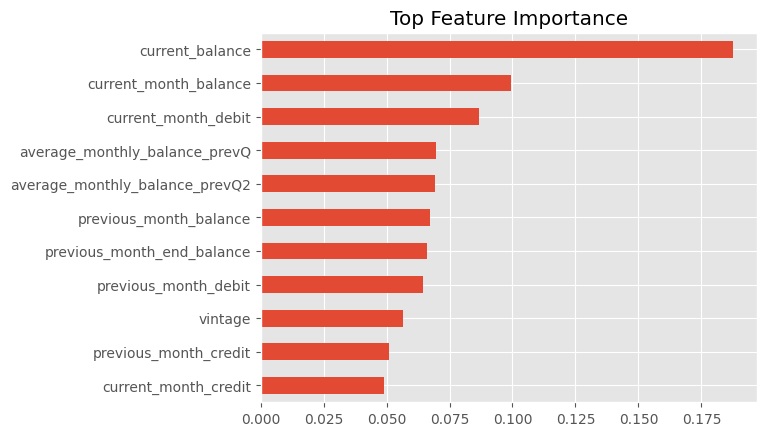

In [27]:
importance.head(11).sort_values(ascending=True).plot(kind='barh', title="Top Feature Importance")


In [28]:
X_train_sel = X_train[top_features]
X_test_sel = X_test[top_features]


In [29]:
smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train_sel, y_train)

print("\nBefore SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_bal).value_counts())



Before SMOTE:
churn
0    18497
1     4208
Name: count, dtype: int64

After SMOTE:
churn
0    18497
1    18497
Name: count, dtype: int64


In [30]:
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test_sel)





In [31]:
models = {

    "LogisticRegression": LogisticRegression(max_iter=2000),

    "DecisionTree": DecisionTreeClassifier(),

    "RandomForest": RandomForestClassifier(n_estimators=300),

    "KNN": KNeighborsClassifier(),

    "SVM": SVC(probability=True),

    "XGBoost": XGBClassifier(eval_metric='logloss'),

    
}



In [32]:
results = []

for name, model in models.items():

    if name in ["LogisticRegression", "KNN", "SVM"]:

        model.fit(X_train_scaled, y_train_bal)

        train_pred = model.predict(X_train_scaled)
        test_pred = model.predict(X_test_scaled)

        train_acc = accuracy_score(y_train_bal, train_pred)

    else:

        model.fit(X_train_bal, y_train_bal)

        train_pred = model.predict(X_train_bal)
        test_pred = model.predict(X_test_sel)

        train_acc = accuracy_score(y_train_bal, train_pred)

    test_acc = accuracy_score(y_test, test_pred)

    results.append([name, train_acc, test_acc])

results_df = pd.DataFrame(results, columns=["Model", "Train Accuracy", "Test Accuracy"])
results_df = results_df.sort_values(by="Test Accuracy", ascending=False)

print("\n===== Model Performance =====")
print(results_df)



===== Model Performance =====
                Model  Train Accuracy  Test Accuracy
2        RandomForest        1.000000       0.839704
4                 SVM        0.736552       0.834948
5             XGBoost        0.909904       0.830720
1        DecisionTree        1.000000       0.745288
3                 KNN        0.851895       0.744231
0  LogisticRegression        0.706574       0.736128


Text(0.5, 1.0, 'Model Evaluation Results (Test Set)')

<Figure size 1000x800 with 0 Axes>

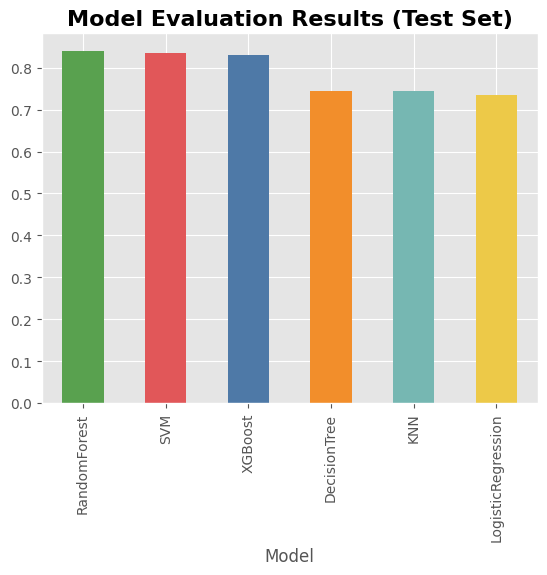

In [33]:
plt.figure(figsize=(10,8))
results_df.plot(x="Model", y="Test Accuracy", kind="bar", legend=False, 
                color=['#59A14F', '#E15759', '#4E79A7', '#F28E2B', '#76B7B2', '#EDC948'])
plt.title("Model Evaluation Results (Test Set)", fontsize=16, fontweight='bold')

In [34]:
rf_model = models["RandomForest"]

rf_pred = rf_model.predict(X_test_sel)


print("Random Forest Classification Report (Test Data)")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report (Test Data)
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      4625
           1       0.56      0.62      0.59      1052

    accuracy                           0.84      5677
   macro avg       0.74      0.76      0.75      5677
weighted avg       0.85      0.84      0.84      5677

